# 실습2. 다중 분류 문제 해결하기
- 분류 예측의 갯수가 3개 이상인 것

In [80]:
# ensorFlow가 시작하자마자 GPU 메모리를 거의 전부 선점하는 것을 막고 필요한 만큼 점진적으로 확보하게 한
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FukxkL%2FbtrK7Czk12T%2Fwk2oWuMLdXXgrgFoDiXSgk%2Fimg.jpg">

- 아이리스는 꽃잎의 모양과 길이에 따라 여러 가지 품종으로 나뉨
-  보면 품종마다 비슷해 보이는데요. 과연 딥러닝을 사용해서 이들을 구별해 낼 수 있을까?

## 붓꽃 데이터 구조
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FblVkOE%2FbtrK6Ri8ILi%2F45WkL4FpIuZtkmhZcEdUIk%2Fimg.jpg">

### feature 정보
- sepal length : 꽃받침 길이
- sepal width : 꽃받침 너비
- petal length : 꽃잎 길이
- petal width : 꽃잎 길이

## 데이터 준비

In [81]:
import pandas as pd

In [82]:
# 데이터 가져오기
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target  # 0,1,2

In [83]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [84]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [85]:
# DataFrame 생성
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 상관도 그래프 그리기

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

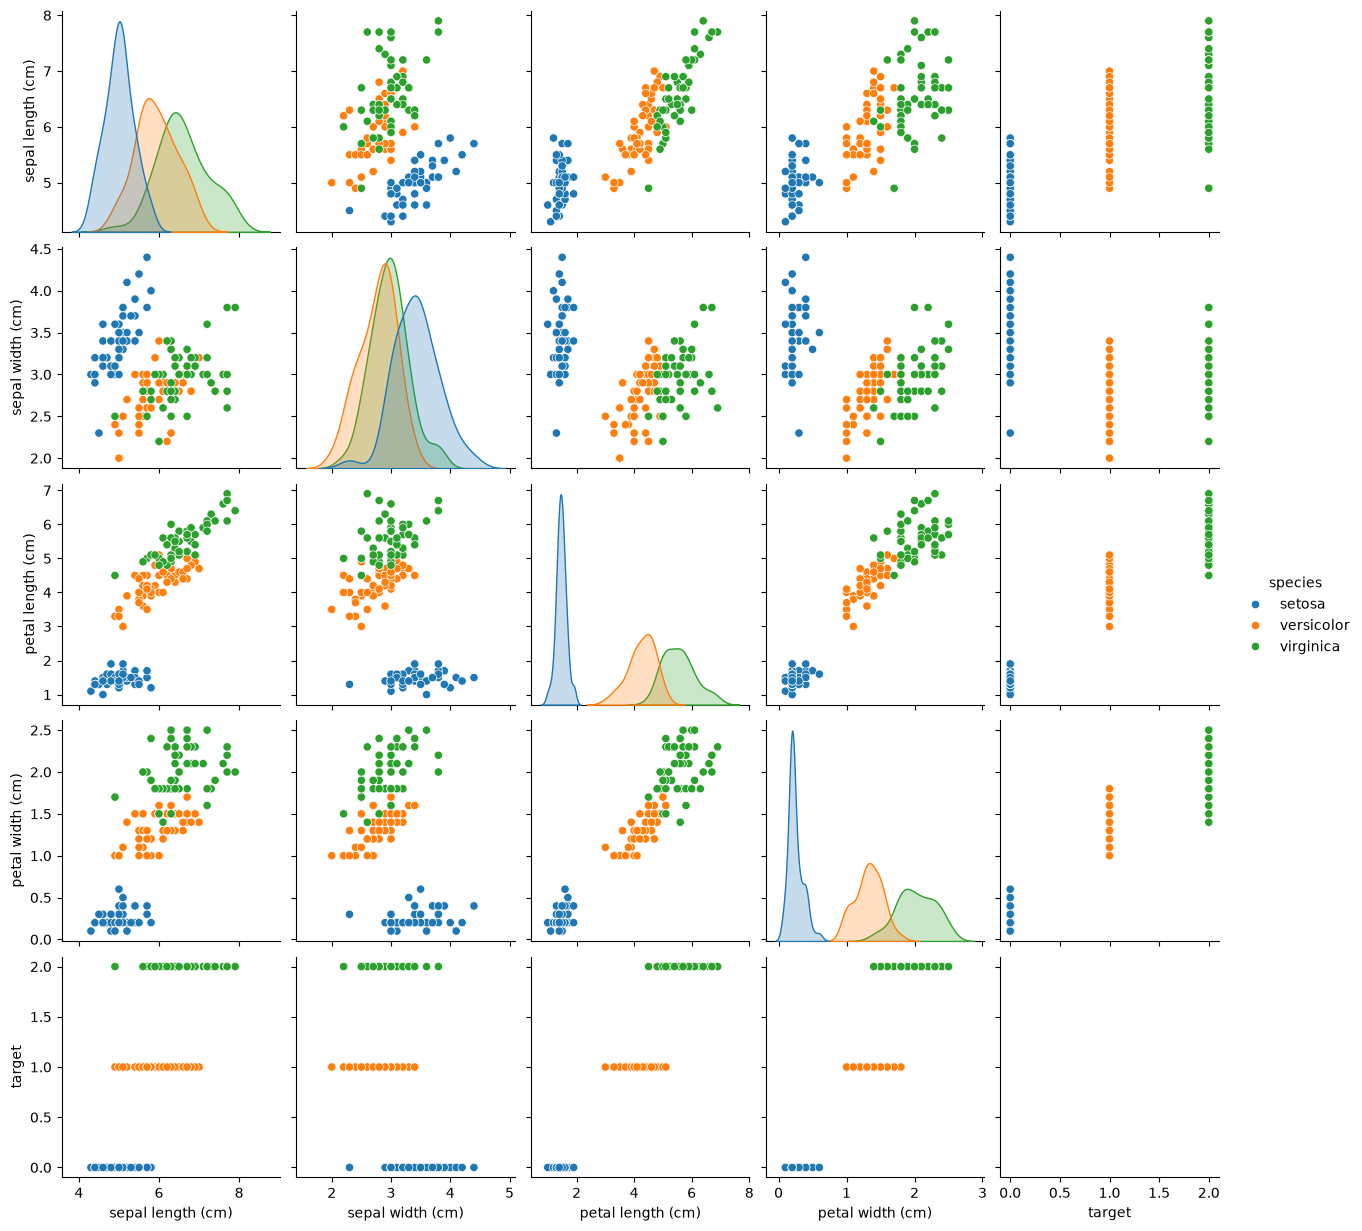

In [87]:
sns.pairplot(df, hue='species')
plt.show()

## X, y 데이터 분할

In [88]:
# X데이터 
X = df.iloc[:, :4]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [89]:
y = df['target']

## 데이터 전처리

In [90]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [91]:
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

### 문자를 숫자형으로 바꾸기
- one-hot encoding(원핫인코딩)  
- pd.get_dummies()

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FbmPutv%2FbtrK5xFBKxx%2FsbX5lPxQdPoiEl3MOUJCKk%2Fimg.jpg">

In [92]:
# 원-핫 인코딩 처리
y = pd.get_dummies(y)
print(y.head())

      0      1      2
0  True  False  False
1  True  False  False
2  True  False  False
3  True  False  False
4  True  False  False


## 학습/테스트 데이터 셋으로 분할

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=88,
    stratify=y
)

## 딥러닝 모델 만들기

### 딥러닝 모델 구조 정의
- 출력층의 노드수 3개(setosa, versicolor, verginica), 다항 분류
- 활성함수(activation) : sfoftmax
- 컴파일(compile) : categorical_crossentropy

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

In [95]:
# 모델 객체 생성
# 입력 4
# 은닉층1 노드 12
# 은닉층2 노드 8
# 출력 3

model = Sequential()

# 독립변수 (칼럼 개수) 4을 입력으로 넣음 
model.add(Input(shape=(4,)))

# 은닉층 
model.add(Dense(12, activation='relu', name='Dense_1')) #  name='Dense_1' 이건 선택
model.add(Dense(8, activation='relu', name='Dense_2')) 

# 출력층
model.add(Dense(3, activation='softmax', name='Dense_3'))

model.summary()  # 딥러닝 모델 구조를 보여줌

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 12)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

### 모델 컬파일

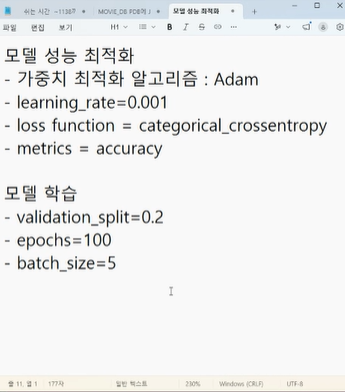

In [96]:
# 정의한 모델이 효과적으로 실행될 수 있도록, loss함수, 최적화 함수, 평가 방법 설정


model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

### 모델 학습

In [97]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=5,
    validation_split=0.2
)



Epoch 1/100


I0000 00:00:1788163392.417746   41948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_49989__.17


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.6146 - loss: 0.8801 - val_accuracy: 0.7500 - val_loss: 0.7304
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6458 - loss: 0.7816 - val_accuracy: 0.7500 - val_loss: 0.6316
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6458 - loss: 0.7083 - val_accuracy: 0.7500 - val_loss: 0.5563
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6562 - loss: 0.6511 - val_accuracy: 0.7500 - val_loss: 0.5038
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6562 - loss: 0.6067 - val_accuracy: 0.7500 - val_loss: 0.4599
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6562 - loss: 0.5706 - val_accuracy: 0.7500 - val_loss: 0.4224
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.5413 - val_accuracy: 0.7917 - val_loss: 0.3956
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.5167 - val_accuracy: 0.7917 - val_loss: 0.

# 모델 평가

In [98]:
score = model.evaluate(X_test, y_test, verbose=1)
print(score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9333 - loss: 0.0934
[0.09341467171907425, 0.9333333373069763]


In [99]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

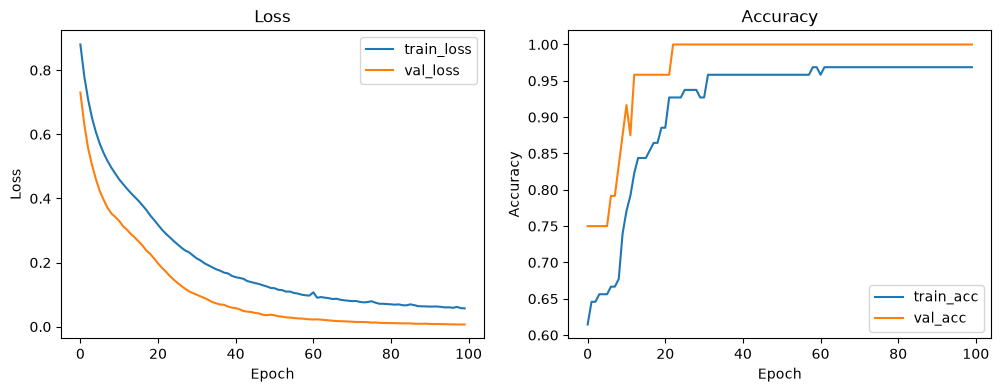

In [100]:
import matplotlib.pyplot as plt

# history는 model.fit()의 반환값
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [101]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

## Confusion Matrix

In [102]:
# X_test 데이터에 대한 확률값 예측
y_pred_proba = model.predict(X_test)

# 확률이 가장 높은 값의 위치 인덱스
y_pred = np.argmax(y_pred_proba, axis=1)

# y의 실제 값
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


## 평가 레포트

In [103]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [104]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba,
    multi_class="ovr",
    average="macro"
)

print(roc_auc)

1.0


In [105]:
# 학습 완료 했으면, gpu 메모리 해제, restart kernel